In [4]:
import pandas as pd
import numpy as np


# 1. 데이터 불러오기
df = pd.read_csv("final_softcone.csv")

# 혹시 이전 실행으로 남아있을 수 있는 코멧 관련 컬럼 제거
drop_cols = ["코멧여부", "코멧score", "코멧유입경로"]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# 기존 컬럼 저장
original_cols = df.columns.tolist()



# 2. 숫자형 컬럼 안전 처리
num_cols = [
    "X_팔로워",
    "유튜브_구독자",
    "최고_팔로워",
    "유튜브_유입지수"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)



# 3. X 유입지수 생성
#    유튜브_유입지수는 기존 컬럼 사용
df["X_유입지수"] = (
    np.log10(df["X_팔로워"] + 1) /
    np.log10(df["최고_팔로워"] + 1)
)

df["X_유입지수"] = (
    df["X_유입지수"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)



# 4. 코멧 후보 조건 생성
# 조건 1: 외부 플랫폼 체급 상위권
top_x = df[df["X_팔로워"] > 0].nlargest(200, "X_팔로워").index
top_yt = df[df["유튜브_구독자"] > 0].nlargest(200, "유튜브_구독자").index

cond1_idx = top_x.union(top_yt)
cond1_mask = df.index.isin(cond1_idx)


# 조건 2: 방송 체급 대비 외부 유입지수 상위권
top_x_inflow = df.nlargest(200, "X_유입지수").index
top_yt_inflow = df.nlargest(200, "유튜브_유입지수").index

cond2_idx = top_x_inflow.union(top_yt_inflow)
cond2_mask = df.index.isin(cond2_idx)



# 5. 코멧여부 생성
df["코멧여부"] = (cond1_mask & cond2_mask).astype(int)

# 제외 대상 처리
df.loc[df["스트리머명"] == "브이레코드", "코멧여부"] = 0



# 6. 코멧유입경로 생성
yt_inflow_cut = df.nlargest(200, "유튜브_유입지수")["유튜브_유입지수"].min()
x_inflow_cut = df.nlargest(200, "X_유입지수")["X_유입지수"].min()

def assign_comet_route(row):
    is_yt = row["유튜브_유입지수"] >= yt_inflow_cut
    is_x = row["X_유입지수"] >= x_inflow_cut

    if is_yt and is_x:
        return "하이브리드"
    elif is_yt:
        return "유튜브 강세형"
    elif is_x:
        return "X 강세형"
    else:
        return "기타"

df["코멧유입경로"] = df.apply(assign_comet_route, axis=1)

# 코멧이 아닌 사람은 비코멧 처리
df.loc[df["코멧여부"] == 0, "코멧유입경로"] = "비코멧"



# 7. 코멧score 생성
#    로그 보정 외부활성도비율 기반

# 의미:
# 방송 체급 대비 외부 팬덤 규모
#
# 기존 단순식:
# (X_팔로워 + 유튜브_구독자) / 최고_팔로워
#
# 변경식:
# log1p(X_팔로워 + 유튜브_구독자) / log1p(최고_팔로워)
#
# 이유:
# 최고_팔로워가 너무 작을 때 점수가 과도하게 튀는 문제 완화

df["_코멧_raw_score"] = (
    np.log1p(df["X_팔로워"] + df["유튜브_구독자"]) /
    np.log1p(df["최고_팔로워"].replace(0, np.nan))
)

df["_코멧_raw_score"] = (
    df["_코멧_raw_score"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .astype("float64")
)

# 코멧 후보 내부에서만 0~100 MinMax
comet_mask = df["코멧여부"] == 1


df["코멧score"] = pd.Series(0.0, index=df.index, dtype="float64")

if comet_mask.sum() > 0:
    comet_raw = df.loc[comet_mask, "_코멧_raw_score"].astype("float64")

    min_val = comet_raw.min()
    max_val = comet_raw.max()

    if max_val == min_val:
        df.loc[comet_mask, "코멧score"] = 100.0
    else:
        comet_score = (
            (comet_raw - min_val)
            / (max_val - min_val)
            * 100
        ).astype("float64")

        df.loc[comet_mask, "코멧score"] = comet_score.values

df["코멧score"] = df["코멧score"].astype("float64").round(2)



# 8. 최종 컬럼 정리
#    기존 컬럼 + 코멧여부 + 코멧score + 코멧유입경로





# 9. 결과 확인
print(f"전체 인원: {len(df)}명")
print(f"코멧 인원: {df['코멧여부'].sum()}명")

print("\n[코멧유입경로 분포]")
print(df[df["코멧여부"] == 1]["코멧유입경로"].value_counts())

print("\n[코멧score 상위 20명]")
print(
    df[df["코멧여부"] == 1]
    .sort_values("코멧score", ascending=False)[
        ["스트리머명", "코멧여부", "코멧score", "코멧유입경로"]
    ]
    .head(20)
)

print("\n[코멧score 100점 인원]")
print((df["코멧score"] == 100).sum())


# 10. 저장
#df.to_csv(
#    "final_softcone_with_comet.csv",
#    index=False,
#    encoding="utf-8-sig"
#)

전체 인원: 11157명
코멧 인원: 68명

[코멧유입경로 분포]
코멧유입경로
X 강세형      50
유튜브 강세형    14
하이브리드       4
Name: count, dtype: int64

[코멧score 상위 20명]
               스트리머명  코멧여부  코멧score   코멧유입경로
10712            앤무디     1   100.00    X 강세형
10895          xesii     1    81.71    하이브리드
8073              냥찬     1    52.87    X 강세형
9999            리아 뇌     1    49.65    하이브리드
3608            나는코히     1    42.98  유튜브 강세형
7161            총며칠ㅡ     1    41.24  유튜브 강세형
8961              수콩     1    35.03    X 강세형
8690            치로미2     1    33.85    X 강세형
5715   DIO fevercell     1    33.20    X 강세형
2403             태비군     1    33.12  유튜브 강세형
6585             리코링     1    33.06    X 강세형
7037             이천일     1    32.96  유튜브 강세형
8039         츠키요미 미호     1    30.41    X 강세형
7055              시신     1    26.61    X 강세형
6464            비하와와     1    25.20    X 강세형
8954          나는 범이요     1    25.10  유튜브 강세형
8855             워니이     1    25.03  유튜브 강세형
4581              우현     1    24.72  유튜브 강세형
7940          

In [5]:
# ============================================================
# 코멧 조건별 통과 현황 확인
# ============================================================

print("=" * 60)
print("[코멧 조건별 통과 현황]")
print("=" * 60)

print(f"조건 1 통과자 수 : {cond1_mask.sum()}명")
print(f"조건 2 통과자 수 : {cond2_mask.sum()}명")
print(f"최종 코멧 통과자 수 : {df['코멧여부'].sum()}명")


# ============================================================
# 조건별 교집합 확인
# ============================================================

print("\n" + "=" * 60)
print("[조건별 교집합 현황]")
print("=" * 60)

print(f"조건1만 통과 : {(cond1_mask & ~cond2_mask).sum()}명")
print(f"조건2만 통과 : {(~cond1_mask & cond2_mask).sum()}명")
print(f"둘 다 통과(최종 코멧) : {(cond1_mask & cond2_mask).sum()}명")
print(f"둘 다 미통과 : {(~cond1_mask & ~cond2_mask).sum()}명")


# ============================================================
# 최종 코멧 후보 확인
# ============================================================

print("\n" + "=" * 60)
print("[최종 코멧 후보 상위 30명]")
print("=" * 60)

display_cols = [
    "스트리머명",
    "최고_팔로워",
    "X_팔로워",
    "유튜브_구독자",
    "X_유입지수",
    "유튜브_유입지수",
    "코멧score",
    "코멧유입경로"
]

display(
    df[df["코멧여부"] == 1]
    .sort_values("코멧score", ascending=False)[display_cols]
    .head(30)
)

[코멧 조건별 통과 현황]
조건 1 통과자 수 : 353명
조건 2 통과자 수 : 378명
최종 코멧 통과자 수 : 68명

[조건별 교집합 현황]
조건1만 통과 : 284명
조건2만 통과 : 309명
둘 다 통과(최종 코멧) : 69명
둘 다 미통과 : 10495명

[최종 코멧 후보 상위 30명]


,스트리머명,최고_팔로워,X_팔로워,유튜브_구독자,X_유입지수,유튜브_유입지수,코멧score,코멧유입경로
10712,앤무디,11,3278,0,3.257786,-100.0,100.00,X 강세형
10895,xesii,23,8060,1800,2.830283,135.9,81.71,하이브리드
8073,냥찬,70,19669,10,2.319398,-43.7,52.87,X 강세형
9999,리아 뇌,43,2878,2210,2.104862,103.5,49.65,하이브리드
3608,나는코히,180,0,62000,0.000000,112.3,42.98,유튜브 강세형
7161,총며칠ㅡ,237,0,91700,0.000000,108.8,41.24,유튜브 강세형
8961,수콩,146,18088,0,1.964371,-100.0,35.03,X 강세형
8690,치로미2,185,25398,0,1.940864,-100.0,33.85,X 강세형
5715,DIO fevercell,439,121000,3850,1.922784,35.6,33.20,X 강세형
2403,태비군,293,0,56900,0.000000,92.6,33.12,유튜브 강세형


In [6]:
# ============================================================
# TOP 200 컷라인 확인
# ============================================================

# 조건 1 컷라인
x_follower_cut = df[df["X_팔로워"] > 0] \
    .nlargest(200, "X_팔로워")["X_팔로워"].min()

yt_subscriber_cut = df[df["유튜브_구독자"] > 0] \
    .nlargest(200, "유튜브_구독자")["유튜브_구독자"].min()

# 조건 2 컷라인
x_inflow_cut = df.nlargest(200, "X_유입지수")["X_유입지수"].min()

yt_inflow_cut = df.nlargest(200, "유튜브_유입지수")["유튜브_유입지수"].min()


# ============================================================
# 컷라인 출력
# ============================================================

print("=" * 60)
print("[코멧 TOP 200 컷라인]")
print("=" * 60)

print(f"조건1 - X 팔로워 TOP200 컷 : {x_follower_cut:,.0f}")
print(f"조건1 - 유튜브 구독자 TOP200 컷 : {yt_subscriber_cut:,.0f}")

print(f"조건2 - X 유입지수 TOP200 컷 : {x_inflow_cut:.4f}")
print(f"조건2 - 유튜브 유입지수 TOP200 컷 : {yt_inflow_cut:.4f}")

[코멧 TOP 200 컷라인]
조건1 - X 팔로워 TOP200 컷 : 2,634
조건1 - 유튜브 구독자 TOP200 컷 : 47,800
조건2 - X 유입지수 TOP200 컷 : 1.2233
조건2 - 유튜브 유입지수 TOP200 컷 : 54.2000


### 코멧유입경로

C:\Users\anna3\AppData\Local\Temp\ipykernel_16012\688700816.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


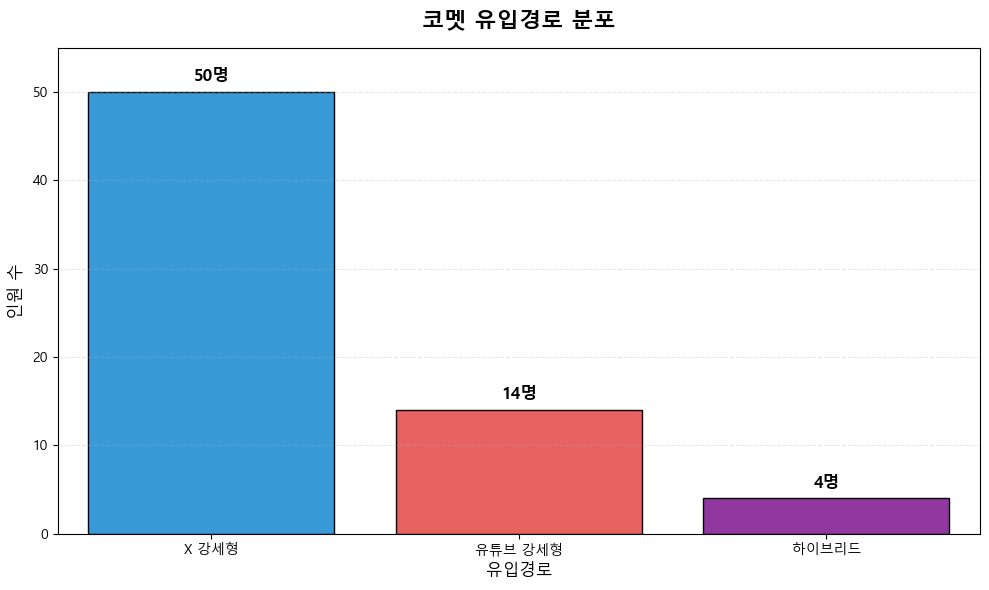

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 코멧 유입경로 분포 시각화
# ============================================================

# 코멧 후보만 사용
comet_df = df[df["코멧여부"] == 1].copy()

# 그래프 순서
order = ["X 강세형", "유튜브 강세형", "하이브리드"]

# 색상 설정
palette = {
    "X 강세형": '#1DA1F2',      # 하늘색
    "유튜브 강세형": "#FF4B4B", # 빨강
    "하이브리드": "#9C27B0"     # 보라
}

# ============================================================
# 그래프 생성
# ============================================================

plt.figure(figsize=(10, 6))

plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

ax = sns.countplot(
    data=comet_df,
    x="코멧유입경로",
    order=order,
    palette=palette,
    edgecolor="black",
    linewidth=1
)

# 막대 위 숫자 표시
for p in ax.patches:
    height = p.get_height()

    if height > 0:
        ax.annotate(
            f"{int(height)}명",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points"
        )

# ============================================================
# 그래프 꾸미기
# ============================================================

plt.title(
    "코멧 유입경로 분포",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("유입경로", fontsize=12)
plt.ylabel("인원 수", fontsize=12)
plt.ylim(0, 55)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 코멧score TOP4

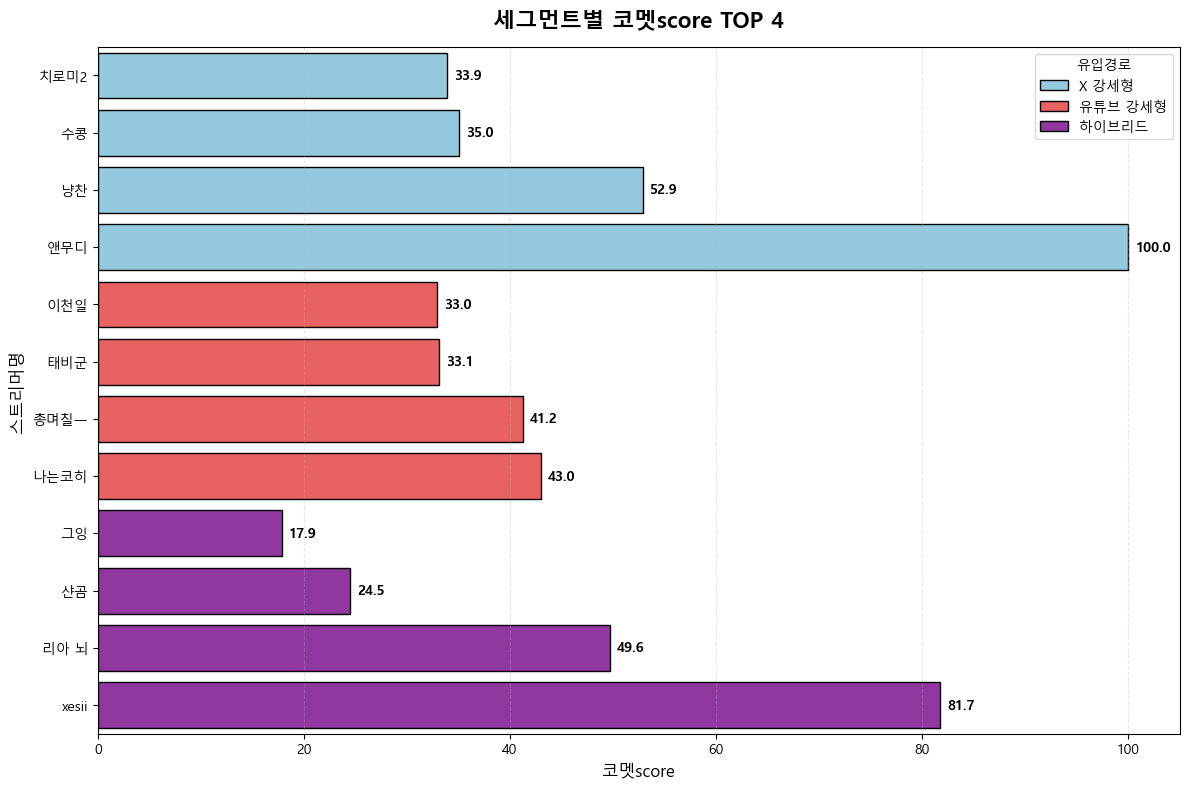

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# 세그먼트별 코멧score TOP 4 추출
# ============================================================

comet_df = df[df["코멧여부"] == 1].copy()

# 세그먼트 순서
group_order = [
    "X 강세형",
    "유튜브 강세형",
    "하이브리드"
]

# 그룹별 TOP4 추출
top_list = []

for group in group_order:

    temp = (
        comet_df[comet_df["코멧유입경로"] == group]
        .sort_values("코멧score", ascending=False)
        .head(4)
        .copy()
    )

    temp["그룹순서"] = group_order.index(group)

    top_list.append(temp)

# 합치기
top_df = pd.concat(top_list)

# 그룹별로 묶이고, 그룹 안에서는 점수순
top_df = top_df.sort_values(
    ["그룹순서", "코멧score"],
    ascending=[True, True]
)


# ============================================================
# 색상 설정
# ============================================================

palette = {
    "X 강세형": "#87CEEB",
    "유튜브 강세형": "#FF4B4B",
    "하이브리드": "#9C27B0"
}


# ============================================================
# 그래프 생성
# ============================================================

plt.figure(figsize=(12, 8))

plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

ax = sns.barplot(
    data=top_df,
    y="스트리머명",
    x="코멧score",
    hue="코멧유입경로",
    dodge=False,
    palette=palette,
    edgecolor="black"
)


# ============================================================
# 점수 표시
# ============================================================

for p in ax.patches:

    width = p.get_width()

    if width > 0:

        ax.annotate(
            f"{width:.1f}",
            (width, p.get_y() + p.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            xytext=(5, 0),
            textcoords="offset points"
        )


# ============================================================
# 그래프 꾸미기
# ============================================================

plt.title(
    "세그먼트별 코멧score TOP 4",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("코멧score", fontsize=12)
plt.ylabel("스트리머명", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.legend(title="유입경로")

plt.tight_layout()
plt.show()

### TOP4 누적 외부화력 보기

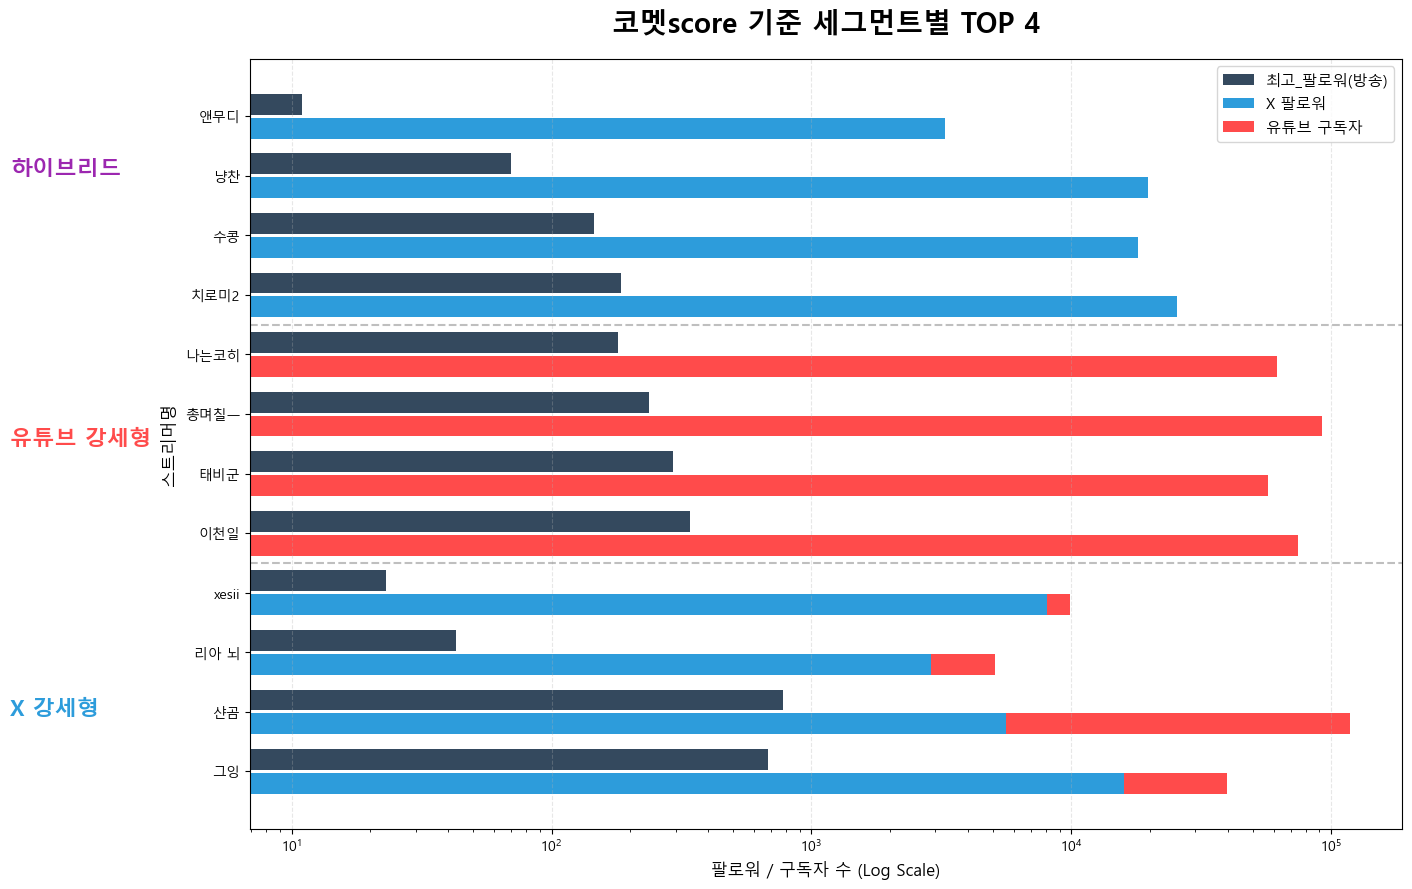

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# 코멧 후보만 추출
# ============================================================

comet_df = df[df["코멧여부"] == 1].copy()

# 그룹 순서
group_order = [
    "X 강세형",
    "유튜브 강세형",
    "하이브리드"
]

# ============================================================
# 코멧score 기준 그룹별 TOP4 추출
# ============================================================

top_list = []

for group in group_order:

    temp = (
        comet_df[comet_df["코멧유입경로"] == group]
        .sort_values("코멧score", ascending=False)
        .head(4)
        .copy()
    )

    temp["그룹순서"] = group_order.index(group)

    top_list.append(temp)

top_df = pd.concat(top_list)

# 그룹별 묶음 정렬
top_df = top_df.sort_values(
    ["그룹순서", "코멧score"],
    ascending=[True, False]
).reset_index(drop=True)

# ============================================================
# 외부 팬덤 누적값 생성
# ============================================================

top_df["X누적"] = top_df["X_팔로워"]
top_df["유튜브누적"] = top_df["유튜브_구독자"]

# ============================================================
# 그래프 생성
# ============================================================

fig, ax = plt.subplots(figsize=(16, 10))

plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

y = np.arange(len(top_df))

# ------------------------------------------------------------
# 방송 팔로워 막대
# ------------------------------------------------------------

ax.barh(
    y - 0.2,
    top_df["최고_팔로워"],
    height=0.35,
    color="#34495E",
    label="최고_팔로워(방송)"
)

# ------------------------------------------------------------
# 외부 팬덤 누적 막대
# ------------------------------------------------------------

# X 팔로워
ax.barh(
    y + 0.2,
    top_df["X누적"],
    height=0.35,
    color="#2D9CDB",
    label="X 팔로워"
)

# 유튜브 구독자 누적
ax.barh(
    y + 0.2,
    top_df["유튜브누적"],
    left=top_df["X누적"],
    height=0.35,
    color="#FF4B4B",
    label="유튜브 구독자"
)

# ============================================================
# 축 설정
# ============================================================

ax.set_yticks(y)
ax.set_yticklabels(top_df["스트리머명"])
ax.invert_yaxis()
ax.set_xscale("log")

ax.set_xlabel("팔로워 / 구독자 수 (Log Scale)", fontsize=12)
ax.set_ylabel("스트리머명", fontsize=12)

ax.set_title(
    "코멧score 기준 세그먼트별 TOP 4",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# ============================================================
# 그룹 구분선
# ============================================================

ax.axhline(3.5, color="gray", linestyle="--", alpha=0.5)
ax.axhline(7.5, color="gray", linestyle="--", alpha=0.5)

# ============================================================
# 왼쪽 그룹 라벨
# ============================================================

# 왼쪽 여백 확보
plt.subplots_adjust(left=0.18)

fig.text(
    0.03,
    0.23,
    "X 강세형",
    fontsize=16,
    fontweight="bold",
    color="#2D9CDB",
    va="center"
)

fig.text(
    0.03,
    0.50,
    "유튜브 강세형",
    fontsize=16,
    fontweight="bold",
    color="#FF4B4B",
    va="center"
)

fig.text(
    0.03,
    0.77,
    "하이브리드",
    fontsize=16,
    fontweight="bold",
    color="#9C27B0",
    va="center"
)

# ============================================================
# 범례 / 그리드
# ============================================================

ax.legend(fontsize=11)

ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

### 코멧타겟팅맵

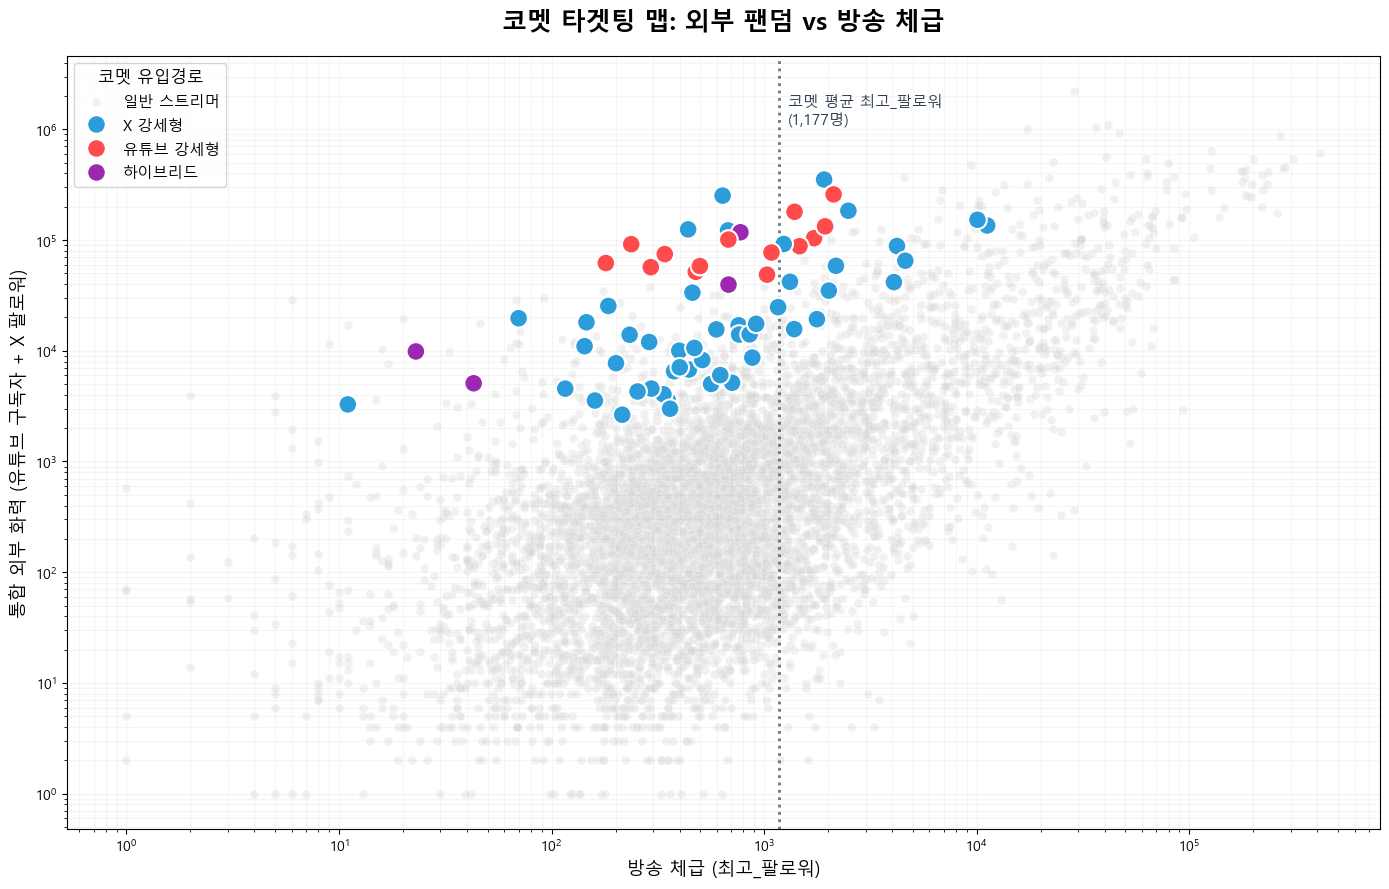

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================================================
# 코멧 후보 데이터
# ============================================================

comet_df = df[df["코멧여부"] == 1].copy()

# ============================================================
# 통합 외부 화력 생성
# ============================================================

df["통합_외부화력"] = (
    df["유튜브_구독자"] +
    df["X_팔로워"]
)

comet_df["통합_외부화력"] = (
    comet_df["유튜브_구독자"] +
    comet_df["X_팔로워"]
)

# ============================================================
# 시각화 설정
# ============================================================

plt.figure(figsize=(14, 9))

plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

# ============================================================
# 전체 스트리머 배경
# ============================================================

sns.scatterplot(
    data=df,
    x="최고_팔로워",
    y="통합_외부화력",
    color="#D9D9D9",
    alpha=0.35,
    s=40,
    label="일반 스트리머"
)

# ============================================================
# 코멧 후보 시각화
# ============================================================

palette = {
    "유튜브 강세형": "#FF4B4B",
    "X 강세형": "#2D9CDB",
    "하이브리드": "#9C27B0"
}

sns.scatterplot(
    data=comet_df,
    x="최고_팔로워",
    y="통합_외부화력",
    hue="코멧유입경로",
    palette=palette,
    s=180,
    edgecolor="white",
    linewidth=1.5,
    zorder=5
)

# ============================================================
# 로그 스케일
# ============================================================

plt.xscale("log")
plt.yscale("log")

# ============================================================
# 코멧 평균 방송 체급 가이드라인
# ============================================================

avg_broadcast = comet_df["최고_팔로워"].mean()

plt.axvline(
    x=avg_broadcast,
    color="#2C3E50",
    linestyle=":",
    linewidth=2,
    alpha=0.7
)

plt.text(
    avg_broadcast * 1.1,
    df["통합_외부화력"].max() * 0.5,
    f"코멧 평균 최고_팔로워\n({int(avg_broadcast):,}명)",
    color="#2C3E50",
    fontsize=11
)

# ============================================================
# 제목 / 축
# ============================================================

plt.title(
    "코멧 타겟팅 맵: 외부 팬덤 vs 방송 체급",
    fontsize=18,
    pad=20,
    fontweight="bold"
)

plt.xlabel(
    "방송 체급 (최고_팔로워)",
    fontsize=13
)

plt.ylabel(
    "통합 외부 화력 (유튜브 구독자 + X 팔로워)",
    fontsize=13
)

# ============================================================
# 범례 / 그리드
# ============================================================

plt.legend(
    title="코멧 유입경로",
    loc="upper left",
    fontsize=11,
    title_fontsize=12
)

plt.grid(
    True,
    which="both",
    linestyle="-",
    alpha=0.12
)

plt.tight_layout()
plt.show()

### 코멧 후보군의 주력 콘텐츠 카테고리 분포

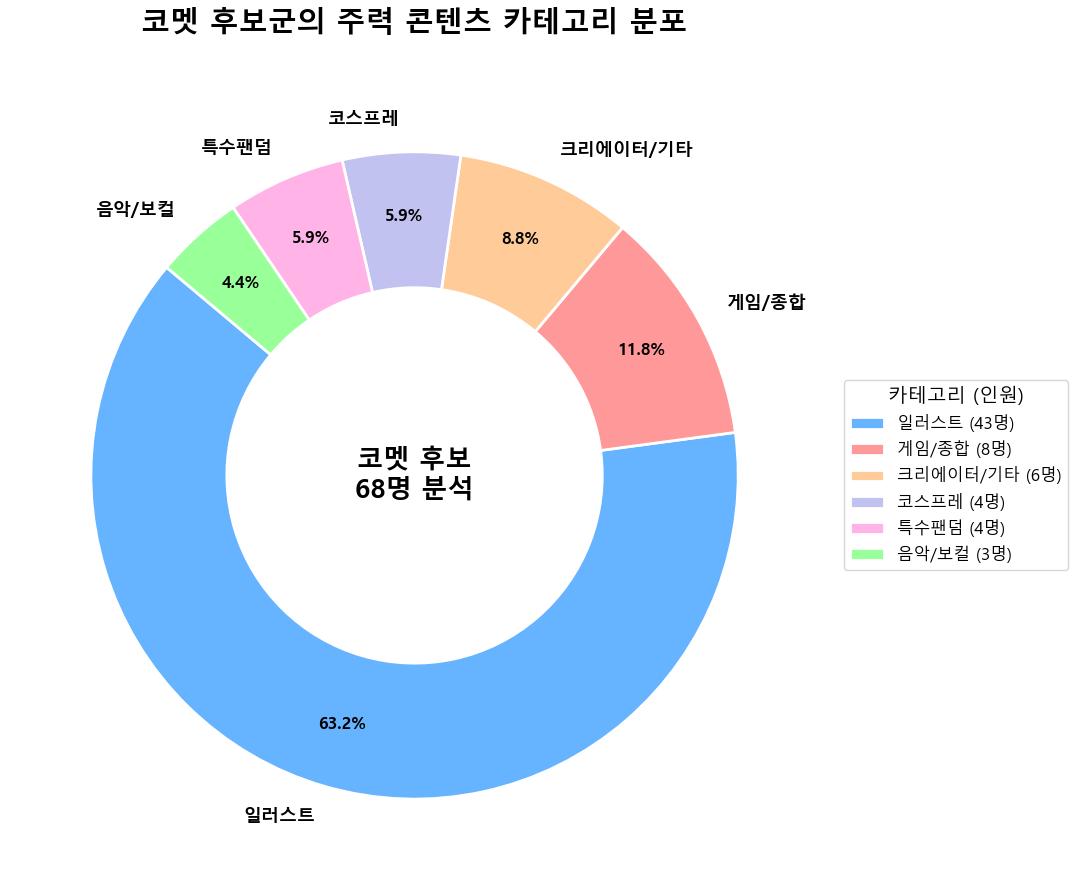

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. 카테고리 데이터
# ============================================================

data = {
    '카테고리': [
        '그림', '그림', '그림', '노래', '그림', '그림', '그림', '그림', '그림', '그림',
        '그림', '그림', '그림', '그림', '그림', '그림', '그림', '그림', '그림', '그림',
        '그림', '버튜버', '코스프레', '특수팬덤', '그림', '그림', '특수팬덤', '그림', '그림', '그림',
        '코스프레', '그림', '그림', '그림', '그림', '그림', '그림', '코스프레', '그림',
        '그림', '그림', '그림', '코스프레', '특수팬덤', '특수팬덤', '그림', '그림', '노래', '그림',
        '게임', '그림', '그림', '그림', '그림', '유튜브', '인터넷방송인클립제작', '유튜브', '게임', '게임',
        '여행/일상', '게임', '공포유튜브', '게임', '노래', '게임', '그림', '게임', '게임'
    ]
}

df_new = pd.DataFrame(data)

# ============================================================
# 2. 발표용 카테고리 정제
# ============================================================

def refine_category(cat):

    if cat == '그림':
        return '일러스트'

    if cat == '게임':
        return '게임/종합'

    if cat == '노래':
        return '음악/보컬'

    if cat in ['코스프레', '특수팬덤']:
        return cat

    # 소수 카테고리 통합
    return '크리에이터/기타'

df_new['정제된_카테고리'] = (
    df_new['카테고리']
    .apply(refine_category)
)

# ============================================================
# 3. 데이터 집계
# ============================================================

cat_counts = (
    df_new['정제된_카테고리']
    .value_counts()
)

labels = cat_counts.index
sizes = cat_counts.values

# ============================================================
# 4. 색상 설정
# ============================================================

colors = [
    '#66B3FF',  # 일러스트
    '#FF9999',  # 게임/종합
    '#FFCC99',  # 음악/보컬
    '#C2C2F0',  # 코스프레
    '#FFB3E6',  # 특수팬덤
    '#99FF99'   # 기타
]

# ============================================================
# 5. 도넛 차트 생성
# ============================================================

fig, ax = plt.subplots(figsize=(12, 9))

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(labels)],
    pctdistance=0.80,
    wedgeprops=dict(
        width=0.42,
        edgecolor='white',
        linewidth=2
    )
)

# ============================================================
# 6. 텍스트 스타일
# ============================================================

for t in texts:
    t.set_fontsize(13)
    t.set_fontweight('bold')

for at in autotexts:
    at.set_fontsize(12)
    at.set_color('black')
    at.set_fontweight('bold')

# ============================================================
# 7. 중앙 텍스트
# ============================================================

plt.text(
    0,
    0,
    f"코멧 후보\n{len(df_new)}명 분석",
    ha='center',
    va='center',
    fontsize=19,
    fontweight='bold'
)

# ============================================================
# 8. 제목
# ============================================================

plt.title(
    '코멧 후보군의 주력 콘텐츠 카테고리 분포',
    fontsize=21,
    pad=28,
    fontweight='bold'
)

# ============================================================
# 9. 범례
# ============================================================

ax.legend(
    wedges,
    [f"{l} ({s}명)" for l, s in zip(labels, sizes)],
    title="카테고리 (인원)",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12,
    title_fontsize=14
)

plt.tight_layout()
plt.show()

**통합_외부화력 : 유튜브_구독자 + X_팔로워**

**코멧score : log1p(X + 유튜브) / log1p(최고_팔로워)**

In [37]:
df = df.drop(columns=["_코멧_raw_score"], errors="ignore")
df.head()

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,...,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,팬카페_그룹여부,X_유입지수,코멧여부,코멧유입경로,코멧score,통합_외부화력
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,...,-13.9,0,537000,46191,False,0.000000,0,비코멧,0.0,537000
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,...,4.1,78000,204000,252724,True,0.914942,0,비코멧,0.0,282000
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,...,-6.2,7028,77600,30431,True,0.780527,0,비코멧,0.0,84628
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,...,4.0,89000,230000,252724,True,0.922149,0,비코멧,0.0,319000
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,...,9.8,0,545000,573411,True,0.000000,0,비코멧,0.0,545000
